In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("nfip_quarterly_adjusted.csv")
df["quarter_dt"] = pd.PeriodIndex(df["quarter"], freq="Q").to_timestamp()
df = df.set_index("quarter_dt")

# Excluimos los últimos 2 trimestres incompletos (rezago de reporte FEMA)
df = df.iloc[:-2]

# Dos ventanas con propósitos distintos: histórico completo para EVT,
# ventana desde el quiebre estructural (2004, confirmado con ruptures/Pelt)
# para SARIMA de frecuencia y severidad.
freq_full = np.log(df["n_claims"])
freq_recent = np.log(df["n_claims"].loc["2004":])

print(f"Ventana completa (EVT): {len(freq_full)} trimestres ({freq_full.index.min().year}-{freq_full.index.max().year})")
print(f"Ventana reciente (SARIMA, desde quiebre 2004): {len(freq_recent)} trimestres ({freq_recent.index.min().year}-{freq_recent.index.max().year})")

Ventana completa (EVT): 192 trimestres (1978-2025)
Ventana reciente (SARIMA, desde quiebre 2004): 88 trimestres (2004-2025)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import genpareto

In [13]:
df = pd.read_csv("nfip_quarterly_adjusted.csv")
df["quarter_dt"] = pd.PeriodIndex(df["quarter"], freq="Q").to_timestamp()
df = df.set_index("quarter_dt")

# Excluimos los últimos 2 trimestres incompletos (rezago de reporte FEMA)
df = df.iloc[:-2]

# Ventana "reciente" para SARIMA, basada en el quiebre estructural
# detectado en 2004 (no un corte arbitrario de "últimos 15 años")
freq_recent = np.log(df["n_claims"].loc["2004":])
sev_recent = np.log(df["avg_severity_real"].loc["2004":])

print(f"Ventana de modelado: {len(freq_recent)} trimestres ({freq_recent.index.min().year}-{freq_recent.index.max().year})")

Ventana de modelado: 88 trimestres (2004-2025)


C:\Users\ramir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\ramir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                          n_claims   No. Observations:                   88
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 4)   Log Likelihood                -127.936
Date:                           Wed, 22 Jul 2026   AIC                            261.872
Time:                                   21:22:54   BIC                            268.981
Sample:                               01-01-2004   HQIC                           264.720
                                    - 10-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0606      0.129      0.470      0.638      -0.192       0.313
ar.S.L4       -0.4623      0.080     -5.777

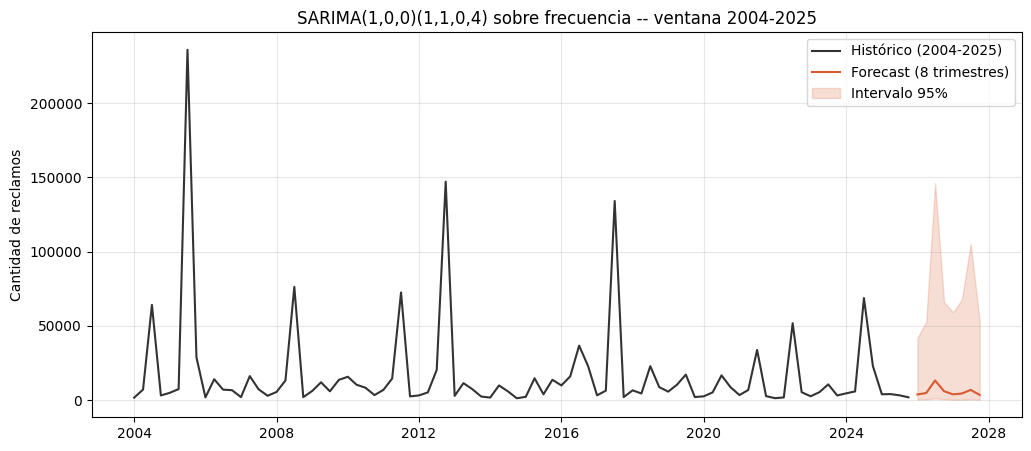

In [14]:
fit_freq = SARIMAX(freq_recent, order=(1,0,0), seasonal_order=(1,1,0,4),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(fit_freq.summary())

fc = fit_freq.get_forecast(steps=8)
mean_fc = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(np.exp(freq_recent).index, np.exp(freq_recent).values, label="Histórico (2004-2025)", color="#333")
ax.plot(mean_fc.index, mean_fc.values, label="Forecast (8 trimestres)", color="#D85A30")
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color="#D85A30", alpha=0.2, label="Intervalo 95%")
ax.set_title("SARIMA(1,0,0)(1,1,0,4) sobre frecuencia -- ventana 2004-2025")
ax.set_ylabel("Cantidad de reclamos")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [15]:
fit_sev = SARIMAX(sev_recent, order=(1,0,1), seasonal_order=(1,1,1,4),
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(fit_sev.summary())

C:\Users\ramir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\ramir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                 avg_severity_real   No. Observations:                   88
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 4)   Log Likelihood                 -42.923
Date:                           Wed, 22 Jul 2026   AIC                             95.846
Time:                                   21:22:54   BIC                            107.630
Sample:                               01-01-2004   HQIC                           100.564
                                    - 10-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5079      0.606     -0.838      0.402      -1.696       0.680
ma.L1          0.5876      0.584      1.007

In [16]:
losses_full = df["total_paid_real"] / 1e6

threshold = np.percentile(losses_full, 90)
exceedances = losses_full[losses_full > threshold] - threshold

print(f"Umbral (percentil 90): ${threshold:,.0f}M")
print(f"Trimestres que superan el umbral: {len(exceedances)} de {len(losses_full)}")

shape, loc, scale = genpareto.fit(exceedances, floc=0)
print(f"Parámetros GPD -- forma (xi): {shape:.3f}, escala (sigma): {scale:.1f}")

def prob_loss_greater_than(x):
    if x <= threshold:
        return np.mean(losses_full > x)
    y = x - threshold
    return (len(exceedances)/len(losses_full)) * (1 + shape * y / scale) ** (-1/shape)

for x in [1000, 4000, 10000, 17000]:
    p = prob_loss_greater_than(x)
    print(f"P(pérdida trimestral > ${x:,}M) = {p:.4f}  (~1 en {1/(p*4):.1f} años)")

Umbral (percentil 90): $1,006M
Trimestres que superan el umbral: 20 de 192
Parámetros GPD -- forma (xi): 1.605, escala (sigma): 519.6
P(pérdida trimestral > $1,000M) = 0.1042  (~1 en 2.4 años)
P(pérdida trimestral > $4,000M) = 0.0244  (~1 en 10.2 años)
P(pérdida trimestral > $10,000M) = 0.0128  (~1 en 19.5 años)
P(pérdida trimestral > $17,000M) = 0.0091  (~1 en 27.6 años)


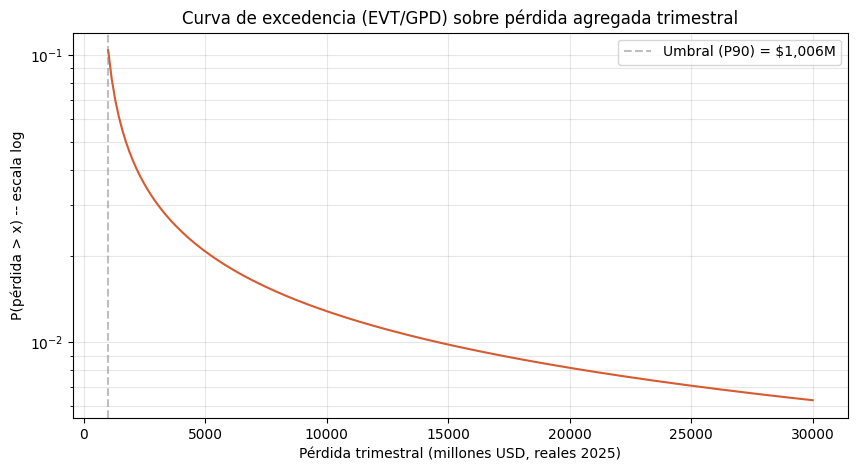

In [17]:
# Curva de excedencia completa -- visualizar la probabilidad de superar
# cualquier umbral, no solo los puntos específicos que ya calculamos
x_vals = np.linspace(threshold, 30000, 200)
y_vals = [prob_loss_greater_than(x) for x in x_vals]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(x_vals, y_vals, color="#D85A30")
ax.set_yscale("log")
ax.set_xlabel("Pérdida trimestral (millones USD, reales 2025)")
ax.set_ylabel("P(pérdida > x) -- escala log")
ax.set_title("Curva de excedencia (EVT/GPD) sobre pérdida agregada trimestral")
ax.grid(alpha=0.3, which="both")
ax.axvline(threshold, color="gray", linestyle="--", alpha=0.5, label=f"Umbral (P90) = ${threshold:,.0f}M")
ax.legend()
plt.show()

In [18]:
# Probabilidad de evento catastrófico, específica por trimestre del año
# (75% de los eventos históricos cayeron en Q3 -- no podemos usar un
# promedio parejo entre los 4 trimestres)
q_counts = df.index.quarter.value_counts().sort_index()
exceed_by_q = df.index[losses_full > threshold].quarter.value_counts().reindex([1,2,3,4], fill_value=0)
prob_cat_by_q = (exceed_by_q / q_counts).to_dict()
print("Probabilidad catastrófica por trimestre:", {k: round(v,3) for k,v in prob_cat_by_q.items()})

STEPS = 8
freq_fc = fit_freq.get_forecast(steps=STEPS)
sev_fc = fit_sev.get_forecast(steps=STEPS)
quarters_fc = freq_fc.predicted_mean.index

np.random.seed(42)
N_SIMS = 20000
rows = []
for i in range(STEPS):
    q = quarters_fc[i].quarter
    p_cat = prob_cat_by_q[q]

    log_freq = np.random.normal(freq_fc.predicted_mean.values[i], freq_fc.se_mean.values[i], N_SIMS)
    log_sev = np.random.normal(sev_fc.predicted_mean.values[i], sev_fc.se_mean.values[i], N_SIMS)
    baseline_loss = (np.exp(log_freq) * np.exp(log_sev)) / 1e6  # a millones, mismo escala que EVT

    is_cat = np.random.random(N_SIMS) < p_cat
    gpd_samples = threshold + genpareto.rvs(shape, loc=0, scale=scale, size=N_SIMS)
    total_loss = np.where(is_cat, np.maximum(baseline_loss, gpd_samples), baseline_loss)

    rows.append({
        "quarter": quarters_fc[i].date(), "prob_evento_catastrofico": round(p_cat, 3),
        "loss_p10_M": np.percentile(total_loss, 10),
        "loss_mediana_M": np.percentile(total_loss, 50),
        "loss_p90_M": np.percentile(total_loss, 90),
        "loss_p99_M": np.percentile(total_loss, 99),
    })

summary = pd.DataFrame(rows)

# CORRECCIÓN: redondear cada columna con su propia precisión, en vez de
# aplicar .round(0) a todo el DataFrame parejo (eso volvía 0 cualquier
# probabilidad menor a 0.5)
summary_display = summary.copy()
summary_display["prob_evento_catastrofico"] = summary_display["prob_evento_catastrofico"].round(3)
for col in ["loss_p10_M", "loss_mediana_M", "loss_p90_M", "loss_p99_M"]:
    summary_display[col] = summary_display[col].round(0)

print(summary_display.to_string(index=False))
summary.to_csv("nfip_final_combined_forecast.csv", index=False)

Probabilidad catastrófica por trimestre: {1: 0.0, 2: 0.062, 3: 0.312, 4: 0.042}
   quarter  prob_evento_catastrofico  loss_p10_M  loss_mediana_M  loss_p90_M  loss_p99_M
2026-01-01                     0.000        23.0           116.0       619.0      2526.0
2026-04-01                     0.062        41.0           227.0      1412.0      7755.0
2026-07-01                     0.312       199.0          1240.0      6300.0     75064.0
2026-10-01                     0.042        42.0           228.0      1354.0      6688.0
2027-01-01                     0.000        18.0           112.0       737.0      3266.0
2027-04-01                     0.062        32.0           217.0      1601.0      9990.0
2027-07-01                     0.312        85.0           942.0      5038.0     86485.0
2027-10-01                     0.042        20.0           133.0      1081.0      6112.0
